In [2]:
import os
import glob
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Dropout,
    BatchNormalization, GlobalAveragePooling2D, Input
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import KFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report


In [34]:
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
print(f'GPU: {len(gpus)} device(s)')
print(f'TensorFlow: {tf.__version__}')


GPU: 1 device(s)
TensorFlow: 2.10.0


In [35]:

SOURCE_DIR  = 'audio_files_augmented'
META_CSV    = 'metadata_augmented.csv'
CACHE_DIR   = 'feature_cache_mt'
MODEL_PATH  = os.path.join('models', 'cnn_multitask.h5')

SAMPLE_RATE = 22050
SAMPLES     = SAMPLE_RATE * 3
N_MELS      = 128
N_FFT       = 2048
HOP_LENGTH  = 512

EMOTION_NAMES   = ['calm','happy','sad','angry','fearful','disgust','surprised']
INTENSITY_NAMES = ['normal','strong']
GENDER_NAMES    = ['male','female']
NUM_EMO = 7
NUM_INT = 2
NUM_GEN = 2

EMOTION_MAP   = {e: i for i, e in enumerate(EMOTION_NAMES)}
INTENSITY_MAP = {'normal': 0, 'strong': 1}
GENDER_MAP    = {'male': 0, 'female': 1}

print('Emotion classes:', EMOTION_NAMES)


Emotion classes: ['calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']


In [36]:
def fix_length(y):
    if len(y) > SAMPLES:
        return y[:SAMPLES]
    pad = SAMPLES - len(y)
    return np.pad(y, (pad // 2, pad - pad // 2), 'constant')

def to_3ch(y, sr):
    mel    = librosa.feature.melspectrogram(
                 y=y, sr=sr, n_mels=N_MELS,
                 n_fft=N_FFT, hop_length=HOP_LENGTH, fmax=8000)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return np.stack([
        mel_db,
        librosa.feature.delta(mel_db),
        librosa.feature.delta(mel_db, order=2)
    ], axis=-1)

def wav_to_feat(path):
    try:
        y, sr = librosa.load(path, sr=SAMPLE_RATE)
        return to_3ch(fix_length(y), sr)
    except Exception as e:
        print(f'  Error: {path} — {e}')
        return None


## Step 1 — Extract features from metadata_augmented.csv 

In [37]:
os.makedirs(CACHE_DIR, exist_ok=True)

cache_X   = os.path.join(CACHE_DIR, 'X.npy')
cache_emo = os.path.join(CACHE_DIR, 'y_emotion.npy')
cache_int = os.path.join(CACHE_DIR, 'y_intensity.npy')
cache_gen = os.path.join(CACHE_DIR, 'y_gender.npy')
cache_src = os.path.join(CACHE_DIR, 'sources.npy')

if all(os.path.exists(p) for p in [cache_X, cache_emo, cache_int, cache_gen, cache_src]):
    X_all       = np.load(cache_X)
    y_emotion   = np.load(cache_emo)
    y_intensity = np.load(cache_int)
    y_gender    = np.load(cache_gen)
    sources     = np.load(cache_src)
    print(f'Cache loaded: {X_all.shape}')
else:
    df = pd.read_csv(META_CSV)
    print(f'Total rows in metadata: {len(df)}')

    feats, emos, ints, gens, srcs = [], [], [], [], []
    skipped = 0

    for i, row in df.iterrows():
        fname     = str(row['file_name'])     
        emotion   = str(row['emotion'])
        intensity = str(row['intensity'])
        gender    = str(row['gender'])

        if emotion not in EMOTION_MAP:
            skipped += 1
            continue

        if not fname.endswith('.wav'):
            fname = fname + '.wav'

        fpath = os.path.join(SOURCE_DIR, fname)
        if not os.path.exists(fpath):
            fpath = os.path.join('audio_files', fname)
            if not os.path.exists(fpath):
                skipped += 1
                continue

        feat = wav_to_feat(fpath)
        if feat is None:
            skipped += 1
            continue
        stem = fname.split('__')[0]

        feats.append(feat)
        emos.append(EMOTION_MAP[emotion])
        ints.append(INTENSITY_MAP.get(intensity, 0))
        gens.append(GENDER_MAP.get(gender, 0))
        srcs.append(stem)

        if i % 300 == 0:
            print(f'  {i}/{len(df)} processed...')

    X_all       = np.array(feats, dtype=np.float32)
    y_emotion   = np.array(emos,  dtype=np.int32)
    y_intensity = np.array(ints,  dtype=np.int32)
    y_gender    = np.array(gens,  dtype=np.int32)
    sources     = np.array(srcs)

    np.save(cache_X,   X_all)
    np.save(cache_emo, y_emotion)
    np.save(cache_int, y_intensity)
    np.save(cache_gen, y_gender)
    np.save(cache_src, sources)
    print(f'Cached: {X_all.shape}  skipped: {skipped}')

print(f'\nTotal samples: {len(y_emotion)}')
print('\nEmotion distribution:')
for i, name in enumerate(EMOTION_NAMES):
    print(f'  {name:<10} {(y_emotion==i).sum():>5}')
print(f'\nIntensity — normal: {(y_intensity==0).sum()}  strong: {(y_intensity==1).sum()}')
print(f'Gender    — male:   {(y_gender==0).sum()}     female: {(y_gender==1).sum()}')


Cache loaded: (3360, 128, 130, 3)

Total samples: 3360

Emotion distribution:
  calm         480
  happy        480
  sad          480
  angry        480
  fearful      480
  disgust      480
  surprised    480

Intensity — normal: 1680  strong: 1680
Gender    — male:   1680     female: 1680


## Step 2 — Multi-task model (shared backbone + 3 heads)

In [38]:
def focal_loss(gamma=2.0):
    """Manual focal loss — compatible with TF 2.10."""
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
        ce     = -y_true * tf.math.log(y_pred)
        weight = y_true * tf.math.pow(1.0 - y_pred, gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * ce, axis=1))
    return loss_fn


def build_multitask_model(input_shape):
    """
    Shared backbone: Conv(32) -> Conv(64) -> Conv(128) -> GAP -> Dense(128)
    Three heads branching from the shared Dense layer:
      - emotion   (7 classes, focal loss, weight=1.0)
      - intensity (2 classes, crossentropy, weight=0.3)
      - gender    (2 classes, crossentropy, weight=0.2)
    Loss weights stop easy tasks (gender ~98%) dominating backbone gradients.
    """
    inp = Input(shape=input_shape)

    x = Conv2D(32, (3,3), activation='relu', padding='same',
               kernel_regularizer=regularizers.l2(0.001))(inp)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)
    x = Dropout(0.25)(x)

    x = Conv2D(64, (3,3), activation='relu', padding='same',
               kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)
    x = Dropout(0.25)(x)

    x = Conv2D(128, (3,3), activation='relu', padding='same',
               kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)
    x = Dropout(0.3)(x)

    shared = GlobalAveragePooling2D()(x)
    shared = Dense(128, activation='relu',
                   kernel_regularizer=regularizers.l2(0.001))(shared)
    shared = Dropout(0.4)(shared)

    # Emotion head — primary task
    h = Dense(64, activation='relu')(shared)
    h = Dropout(0.3)(h)
    out_emotion = Dense(NUM_EMO, activation='softmax', name='emotion')(h)

    # Intensity head — auxiliary
    h = Dense(32, activation='relu')(shared)
    h = Dropout(0.2)(h)
    out_intensity = Dense(NUM_INT, activation='softmax', name='intensity')(h)

    # Gender head — auxiliary
    h = Dense(32, activation='relu')(shared)
    h = Dropout(0.2)(h)
    out_gender = Dense(NUM_GEN, activation='softmax', name='gender')(h)

    model = Model(inputs=inp,
                  outputs=[out_emotion, out_intensity, out_gender])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss={
            'emotion':   focal_loss(gamma=2.0),
            'intensity': 'categorical_crossentropy',
            'gender':    'categorical_crossentropy',
        },
        loss_weights={'emotion': 1.0, 'intensity': 0.3, 'gender': 0.2},
        metrics={
            'emotion':   'accuracy',
            'intensity': 'accuracy',
            'gender':    'accuracy',
        }
    )
    return model

# Sanity check
_m = build_multitask_model((128, 130, 3))
_m.summary()
del _m
tf.keras.backend.clear_session()


Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 128, 130, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_3 (Conv2D)              (None, 128, 130, 32  896         ['input_2[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization_3 (BatchNo  (None, 128, 130, 32  128        ['conv2d_3[0][0]']               
 rmalization)                   )                                                           

## Step 3 — Training (5-fold, leakage-proof split on original stems)

In [39]:
BATCH_SIZE = 64

def make_dataset_mt(X, y_emo, y_int, y_gen, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((
        X,
        {'emotion': y_emo, 'intensity': y_int, 'gender': y_gen}
    ))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), reshuffle_each_iteration=True)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


unique_sources = np.unique(sources)
kfold          = KFold(n_splits=5, shuffle=True, random_state=42)
fold_results   = []

for fold, (tr_src_idx, va_src_idx) in enumerate(kfold.split(unique_sources)):
    print(f'\n── Fold {fold+1}/5 ──')

    tr_stems = set(unique_sources[tr_src_idx])
    va_stems = set(unique_sources[va_src_idx])

    tr_mask = np.array([s in tr_stems for s in sources])
    va_mask = np.array([s in va_stems for s in sources])

    X_tr = X_all[tr_mask].astype(np.float32)
    X_va = X_all[va_mask].astype(np.float32)

    ye_tr = y_emotion[tr_mask];   ye_va = y_emotion[va_mask]
    yi_tr = y_intensity[tr_mask]; yi_va = y_intensity[va_mask]
    yg_tr = y_gender[tr_mask];    yg_va = y_gender[va_mask]

    train_ds = make_dataset_mt(
        X_tr,
        to_categorical(ye_tr, NUM_EMO),
        to_categorical(yi_tr, NUM_INT),
        to_categorical(yg_tr, NUM_GEN),
        shuffle=True
    )
    val_ds = make_dataset_mt(
        X_va,
        to_categorical(ye_va, NUM_EMO),
        to_categorical(yi_va, NUM_INT),
        to_categorical(yg_va, NUM_GEN),
    )

    print(f'  Train: {len(X_tr)}  Val: {len(X_va)}')

    tf.keras.backend.clear_session()
    model = build_multitask_model(X_tr.shape[1:])

    callbacks = [
        ReduceLROnPlateau(monitor='val_emotion_accuracy',
                          patience=7, factor=0.5, min_lr=1e-5, verbose=0),
        EarlyStopping(monitor='val_emotion_accuracy',
                      patience=20, restore_best_weights=True)
    ]

    model.fit(
        train_ds,
        epochs=120,
        validation_data=val_ds,
        callbacks=callbacks,
        verbose=1
    )

    preds    = model.predict(val_ds, verbose=0)
    pred_emo = np.argmax(preds[0], axis=1)
    pred_int = np.argmax(preds[1], axis=1)
    pred_gen = np.argmax(preds[2], axis=1)

    acc_emo = np.mean(pred_emo == ye_va)
    acc_int = np.mean(pred_int == yi_va)
    acc_gen = np.mean(pred_gen == yg_va)

    fold_results.append({
        'fold': fold+1, 'model': model,
        'acc_emo': acc_emo, 'acc_int': acc_int, 'acc_gen': acc_gen,
        'pred_emo': pred_emo, 'true_emo': ye_va,
        'pred_int': pred_int, 'true_int': yi_va,
        'pred_gen': pred_gen, 'true_gen': yg_va,
    })
    print(f'  emotion={acc_emo:.4f}  intensity={acc_int:.4f}  gender={acc_gen:.4f}')

best  = max(fold_results, key=lambda x: x['acc_emo'])
model = best['model']
print(f'\nEmotion   mean={np.mean([r["acc_emo"] for r in fold_results]):.4f}')
print(f'Intensity mean={np.mean([r["acc_int"] for r in fold_results]):.4f}')
print(f'Gender    mean={np.mean([r["acc_gen"] for r in fold_results]):.4f}')
print(f'Best fold: {best["fold"]}')



── Fold 1/5 ──
  Train: 2692  Val: 668
Epoch 1/120
43/43 [==============================] - 5s 72ms/step - loss: 2.0607 - emotion_loss: 1.4542 - intensity_loss: 0.7036 - gender_loss: 0.7154 - emotion_accuracy: 0.1802 - intensity_accuracy: 0.5360 - gender_accuracy: 0.5334 - val_loss: 2.2289 - val_emotion_loss: 1.6378 - val_intensity_loss: 0.6951 - val_gender_loss: 0.6943 - val_emotion_accuracy: 0.1632 - val_intensity_accuracy: 0.5000 - val_gender_accuracy: 0.5344 - lr: 0.0010
Epoch 2/120
43/43 [==============================] - 3s 60ms/step - loss: 1.8733 - emotion_loss: 1.2978 - intensity_loss: 0.6832 - gender_loss: 0.6699 - emotion_accuracy: 0.2467 - intensity_accuracy: 0.5539 - gender_accuracy: 0.5914 - val_loss: 1.9789 - val_emotion_loss: 1.4076 - val_intensity_loss: 0.6945 - val_gender_loss: 0.6688 - val_emotion_accuracy: 0.1737 - val_intensity_accuracy: 0.5195 - val_gender_accuracy: 0.6452 - lr: 0.0010
Epoch 3/120
43/43 [==============================] - 3s 61ms/step - loss: 1.70

## Step 4 — Evaluation

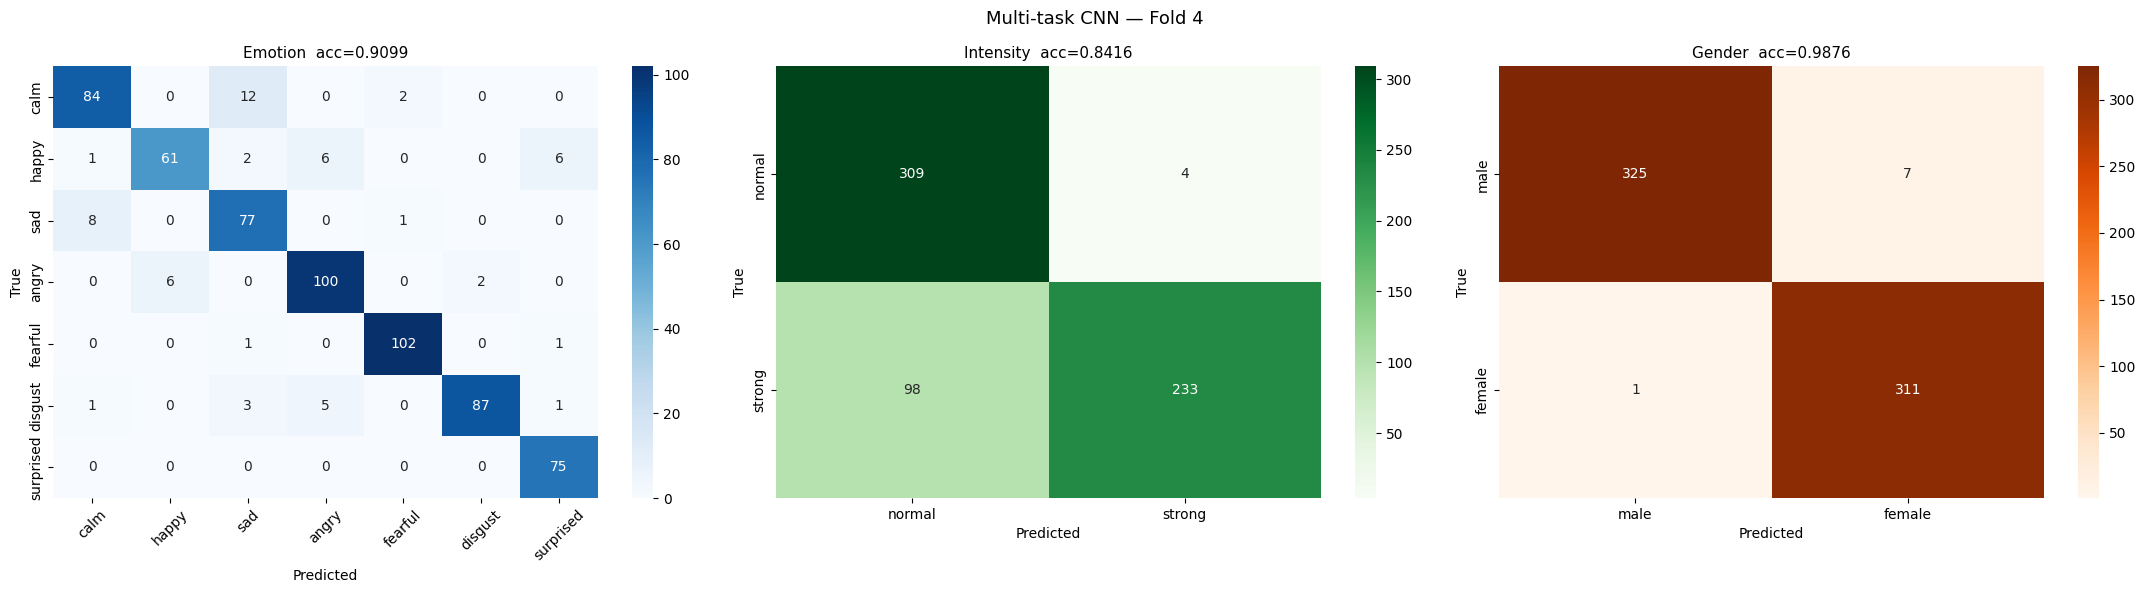

── Emotion ──
              precision    recall  f1-score   support

        calm       0.89      0.86      0.88        98
       happy       0.91      0.80      0.85        76
         sad       0.81      0.90      0.85        86
       angry       0.90      0.93      0.91       108
     fearful       0.97      0.98      0.98       104
     disgust       0.98      0.90      0.94        97
   surprised       0.90      1.00      0.95        75

    accuracy                           0.91       644
   macro avg       0.91      0.91      0.91       644
weighted avg       0.91      0.91      0.91       644

── Intensity ──
              precision    recall  f1-score   support

      normal       0.76      0.99      0.86       313
      strong       0.98      0.70      0.82       331

    accuracy                           0.84       644
   macro avg       0.87      0.85      0.84       644
weighted avg       0.87      0.84      0.84       644

── Gender ──
              precision    recall

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

cm_emo = confusion_matrix(best['true_emo'], best['pred_emo'])
sns.heatmap(cm_emo, annot=True, fmt='d', cmap='Blues',
            xticklabels=EMOTION_NAMES, yticklabels=EMOTION_NAMES, ax=axes[0])
axes[0].set_title(f'Emotion  acc={best["acc_emo"]:.4f}', fontsize=11)
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')
axes[0].tick_params(axis='x', rotation=45)

cm_int = confusion_matrix(best['true_int'], best['pred_int'])
sns.heatmap(cm_int, annot=True, fmt='d', cmap='Greens',
            xticklabels=INTENSITY_NAMES, yticklabels=INTENSITY_NAMES, ax=axes[1])
axes[1].set_title(f'Intensity  acc={best["acc_int"]:.4f}', fontsize=11)
axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')

cm_gen = confusion_matrix(best['true_gen'], best['pred_gen'])
sns.heatmap(cm_gen, annot=True, fmt='d', cmap='Oranges',
            xticklabels=GENDER_NAMES, yticklabels=GENDER_NAMES, ax=axes[2])
axes[2].set_title(f'Gender  acc={best["acc_gen"]:.4f}', fontsize=11)
axes[2].set_ylabel('True'); axes[2].set_xlabel('Predicted')

plt.suptitle(f'Multi-task CNN — Fold {best["fold"]}', fontsize=13)
plt.tight_layout()
plt.show()

print('── Emotion ──')
print(classification_report(best['true_emo'], best['pred_emo'],
                            target_names=EMOTION_NAMES))
print('── Intensity ──')
print(classification_report(best['true_int'], best['pred_int'],
                            target_names=INTENSITY_NAMES))
print('── Gender ──')
print(classification_report(best['true_gen'], best['pred_gen'],
                            target_names=GENDER_NAMES))


## Step 5 — Save to models/

In [41]:
os.makedirs('models', exist_ok=True)
model.save(MODEL_PATH)
print(f'Saved: {MODEL_PATH}')


Saved: models\cnn_multitask.h5


## Predict on your own voice files

In [2]:
import os
import glob
import numpy as np
import librosa
import tensorflow as tf

MODEL_PATH = os.path.join('models', 'cnn_multitask.h5')
SAMPLE_RATE = 22050
SAMPLES = SAMPLE_RATE * 3
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512

EMOTION_NAMES = ['calm','happy','sad','angry','fearful','disgust','surprised']
INTENSITY_NAMES = ['normal','strong']
GENDER_NAMES = ['male','female']

def fix_length(y):
    if len(y) > SAMPLES:
        return y[:SAMPLES]
    pad = SAMPLES - len(y)
    return np.pad(y, (pad // 2, pad - pad // 2), 'constant')

def to_3ch(y, sr):
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=N_MELS,
        n_fft=N_FFT, hop_length=HOP_LENGTH, fmax=8000)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return np.stack([
        mel_db,
        librosa.feature.delta(mel_db),
        librosa.feature.delta(mel_db, order=2)
    ], axis=-1)

def focal_loss(gamma=2.0):
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
        ce = -y_true * tf.math.log(y_pred)
        weight = y_true * tf.math.pow(1.0 - y_pred, gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * ce, axis=1))
    return loss_fn

model = tf.keras.models.load_model(MODEL_PATH, custom_objects={'loss_fn': focal_loss()})

test_files = sorted(glob.glob('test_file/*.wav')+glob.glob('test_file\\*.m4a'))
if not test_files:
    print('No files found in test_file/ — add your WAV recordings there')
else:
    print(f'Found {len(test_files)} test files\n')
    print(f'{"File":<28} {"Emotion":<12} {"Intensity":<11} {"Gender":<8} {"Conf":>5}')
    print('─' * 68)

    for test_file in test_files:
        y, sr = librosa.load(test_file, sr=SAMPLE_RATE)
        feat  = to_3ch(fix_length(y), sr)[np.newaxis, ...]
        preds = model.predict(feat, verbose=0)

        ei   = np.argmax(preds[0][0])
        ii   = np.argmax(preds[1][0])
        gi   = np.argmax(preds[2][0])
        conf = preds[0][0][ei]

        print(f'{os.path.basename(test_file):<28} '
              f'{EMOTION_NAMES[ei]:<12} '
              f'{INTENSITY_NAMES[ii]:<11} '
              f'{GENDER_NAMES[gi]:<8} '
              f'{conf:.3f}')


Found 23 test files

File                         Emotion      Intensity   Gender    Conf
────────────────────────────────────────────────────────────────────
1.wav                        calm         normal      male     0.529
10.wav                       disgust      normal      male     0.909
11.wav                       fearful      normal      female   0.625
12.wav                       surprised    strong      female   0.707
13.wav                       surprised    strong      female   0.283
14.wav                       fearful      strong      female   0.829
15.wav                       surprised    strong      male     0.998
16.wav                       angry        normal      male     0.584
2.wav                        surprised    strong      female   0.966
3.wav                        surprised    strong      female   0.742
4.wav                        fearful      strong      female   0.804
5.wav                        happy        strong      female   0.711
6.wav        

C:\Users\Zyne\AppData\Local\Temp\ipykernel_16868\704412141.py:54: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(test_file, sr=SAMPLE_RATE)


angry_sein.m4a               fearful      strong      female   0.564
calm_sein.m4a                calm         strong      male     0.516
disgust_sein.m4a             sad          normal      male     0.564
fearful_sein.m4a             sad          normal      female   0.602
happy_sein.m4a               sad          normal      female   0.496
sad_sein.m4a                 calm         strong      male     0.759
suprised_sein.m4a            surprised    strong      female   0.869


Loaded model: models\cnn_multitask.h5


c:\Users\Zyne\anaconda3\envs\tf-gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


----------------------------------------------------------------------
  Lamin - 10 files
  File                 True         Pred           Conf  OK?
  ----------------------------------------------------------
  2_1                  calm         calm         0.715  OK
  2_2                  calm         calm         0.771  OK
  3_1                  happy        happy        0.881  OK
  3_2                  happy        happy        0.527  OK
  4_1                  sad          sad          0.856  OK
  5_1                  angry        angry        0.845  OK
  6_1                  sad          sad          0.677  OK
  6_2                  fearful      happy        0.366  X
  7_1                  disgust      disgust      0.616  OK
  8_1                  surprised    surprised    0.490  OK
  Accuracy -> Emotion: 90.0% | Intensity: 80.0% | Gender: 80.0%
----------------------------------------------------------------------
  Sein - 11 files
  File                 True         Pred      

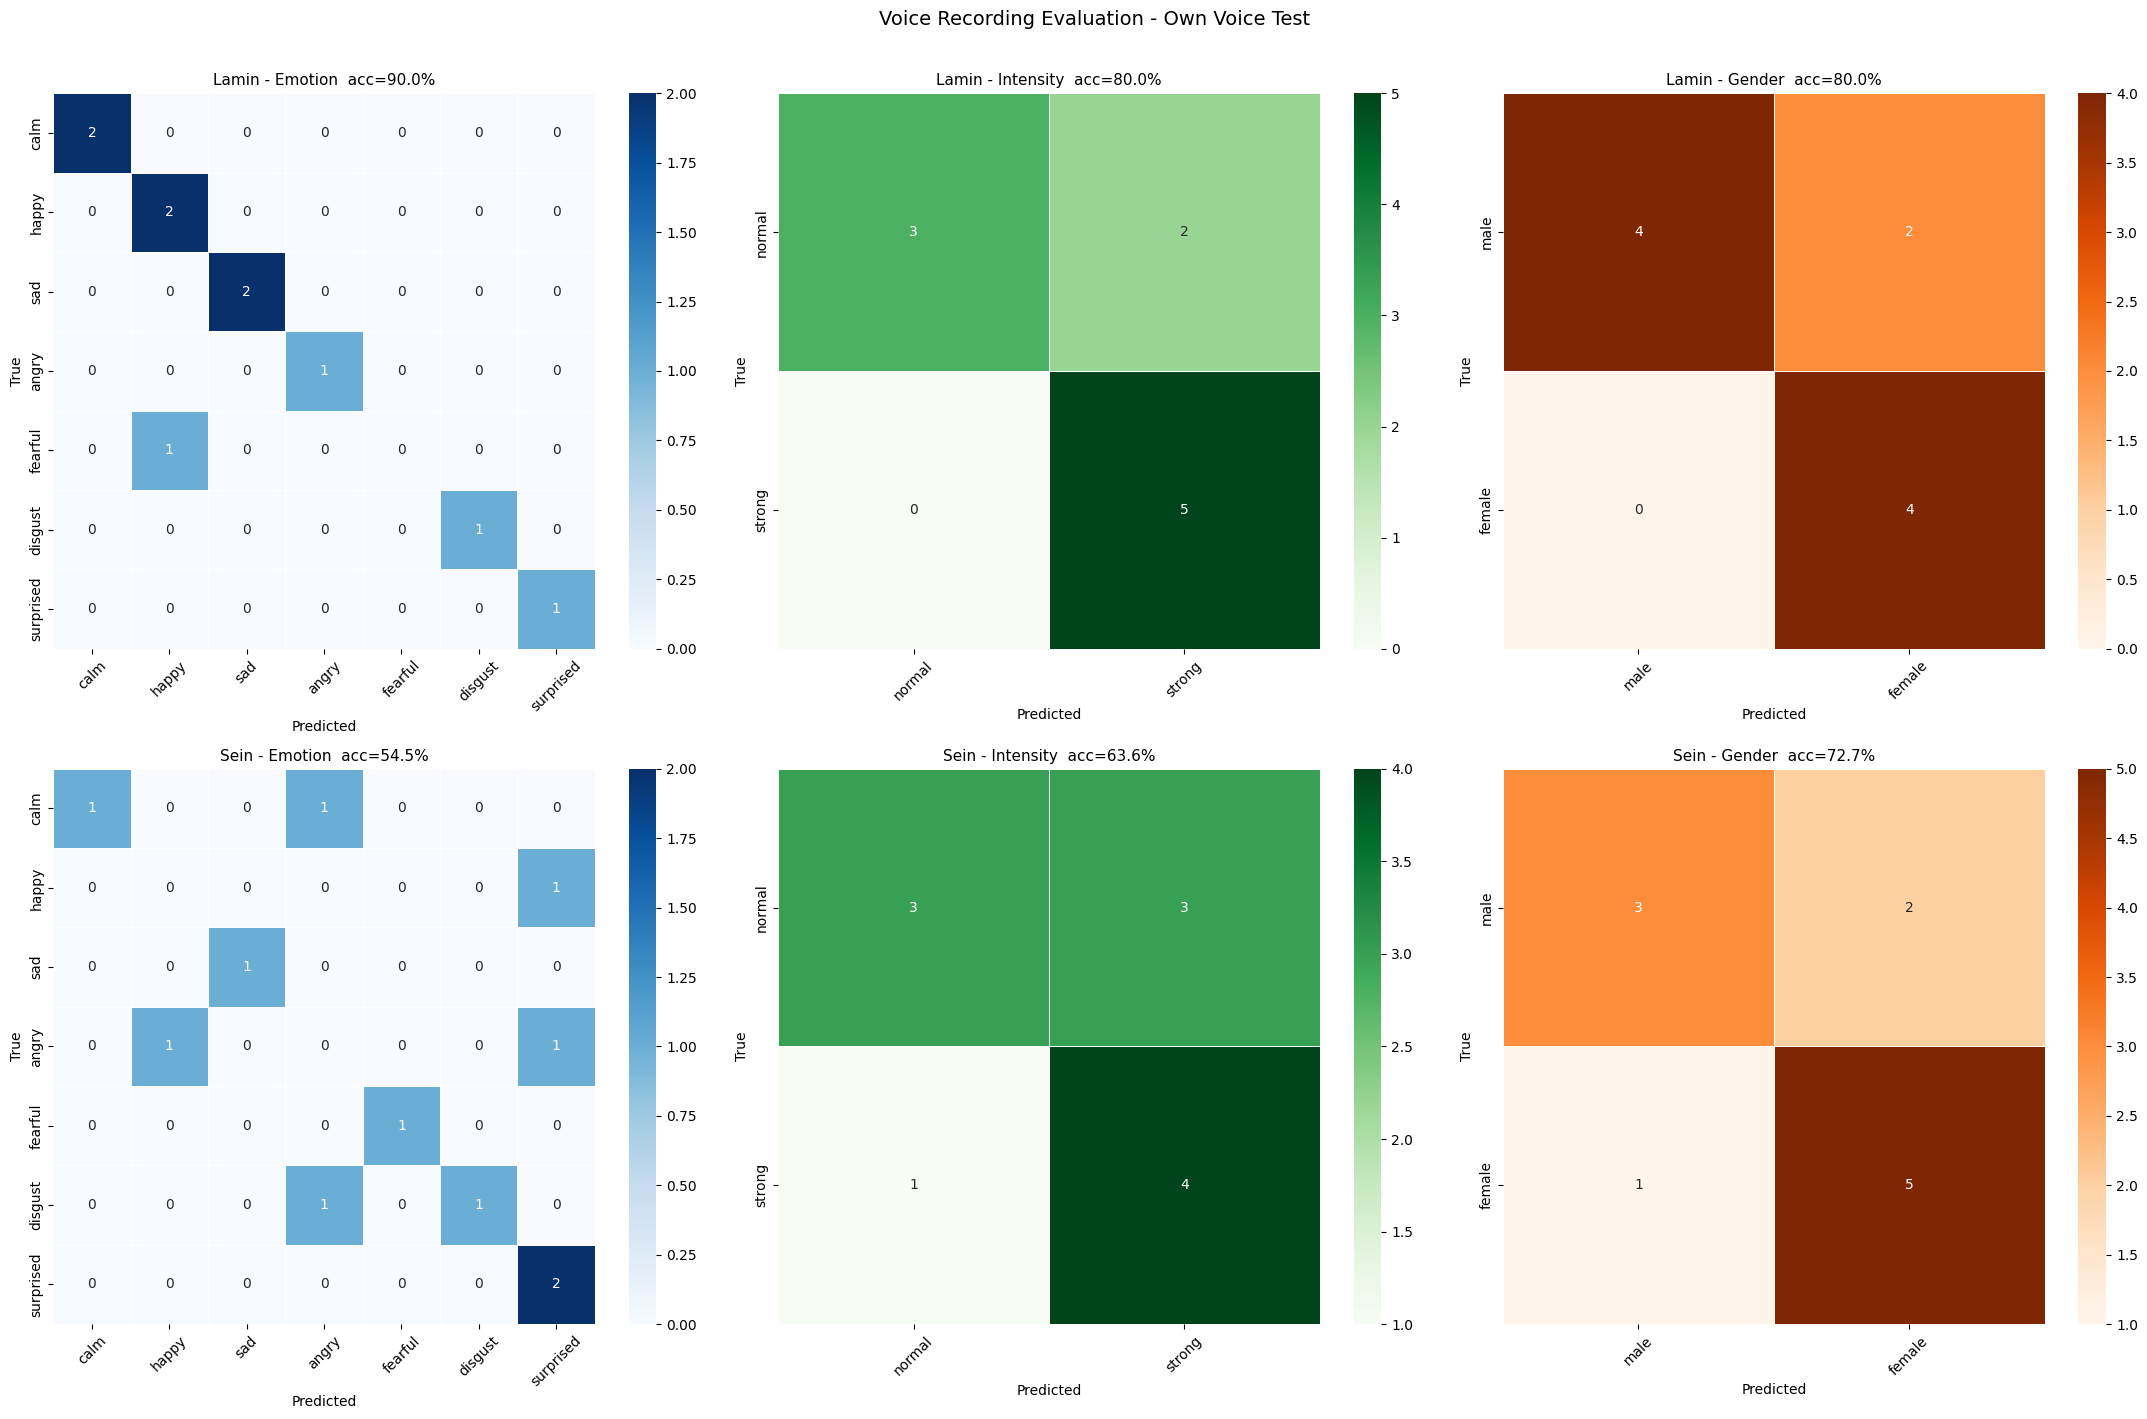

Saved: voice_confusion_matrix.png
-- Lamin - Emotion --
              precision    recall  f1-score   support

        calm       1.00      1.00      1.00         2
       happy       0.67      1.00      0.80         2
         sad       1.00      1.00      1.00         2
       angry       1.00      1.00      1.00         1
     fearful       0.00      0.00      0.00         1
     disgust       1.00      1.00      1.00         1
   surprised       1.00      1.00      1.00         1

    accuracy                           0.90        10
   macro avg       0.81      0.86      0.83        10
weighted avg       0.83      0.90      0.86        10

-- Sein - Emotion --
              precision    recall  f1-score   support

        calm       1.00      0.50      0.67         2
       happy       0.00      0.00      0.00         1
         sad       1.00      1.00      1.00         1
       angry       0.00      0.00      0.00         2
     fearful       1.00      1.00      1.00         1
 

In [1]:
import os
import pandas as pd
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report

EMOTION_NAMES   = ["calm","happy","sad","angry","fearful","disgust","surprised"]
INTENSITY_NAMES = ["normal","strong"]
GENDER_NAMES    = ["male","female"]
SAMPLE_RATE = 22050
SAMPLES     = SAMPLE_RATE * 3
N_MELS, N_FFT, HOP_LENGTH = 128, 2048, 512
MODEL_PATH = os.path.join("models", "cnn_multitask.h5")

def ensure_model_loaded():
    global model
    if "model" not in globals() or model is None:
        if not os.path.exists(MODEL_PATH):
            raise FileNotFoundError(f"Model not found: {MODEL_PATH}")
        model = tf.keras.models.load_model(MODEL_PATH, compile=False)
        print(f"Loaded model: {MODEL_PATH}")

ensure_model_loaded()

def fix_length(y):
    if len(y) > SAMPLES: return y[:SAMPLES]
    pad = SAMPLES - len(y)
    return np.pad(y, (pad//2, pad - pad//2), "constant")

def to_3ch(y, sr):
    mel    = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS,
                 n_fft=N_FFT, hop_length=HOP_LENGTH, fmax=8000)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return np.stack([mel_db,
                     librosa.feature.delta(mel_db),
                     librosa.feature.delta(mel_db, order=2)], axis=-1)

def predict_file(fpath):
    y, sr = librosa.load(fpath, sr=SAMPLE_RATE)
    feat  = to_3ch(fix_length(y), sr)[np.newaxis, ...]
    preds = model.predict(feat, verbose=0)
    return (
        EMOTION_NAMES[np.argmax(preds[0][0])],
        INTENSITY_NAMES[np.argmax(preds[1][0])],
        GENDER_NAMES[np.argmax(preds[2][0])],
        float(np.max(preds[0][0]))
    )

def run_person(name, meta_csv, audio_folder):
    """Load metadata, predict each file, return results dict."""
    df = pd.read_csv(meta_csv)
    true_emo, pred_emo = [], []
    true_int, pred_int = [], []
    true_gen, pred_gen = [], []
    details = []
    missing = []

    for _, row in df.iterrows():
        fpath = os.path.join(audio_folder, str(row["AudioID"]) + ".wav")
        if not os.path.exists(fpath):
            fpath = fpath.replace(".wav", ".m4a")
        if not os.path.exists(fpath):
            missing.append(str(row["AudioID"]))
            continue

        gt_emo = str(row["Emotion"]).lower().strip()
        gt_int = str(row["Intensity"]).lower().strip()
        gt_gen = str(row["Gender"]).lower().strip()

        if gt_emo == "suprised": gt_emo = "surprised"

        if gt_emo not in EMOTION_NAMES:
            print(f"  Unknown emotion: {gt_emo} - skipping")
            continue

        p_emo, p_int, p_gen, conf = predict_file(fpath)

        true_emo.append(gt_emo);  pred_emo.append(p_emo)
        true_int.append(gt_int);  pred_int.append(p_int)
        true_gen.append(gt_gen);  pred_gen.append(p_gen)
        details.append({
            "file": str(row["AudioID"]),
            "true_emo": gt_emo, "pred_emo": p_emo,
            "true_int": gt_int, "pred_int": p_int,
            "true_gen": gt_gen, "pred_gen": p_gen,
            "conf": conf,
            "correct_emo": gt_emo == p_emo,
            "correct_int": gt_int == p_int,
            "correct_gen": gt_gen == p_gen
        })

    if missing:
        print(f"  [{name}] Missing files: {missing}")

    return {
        "name": name,
        "true_emo": true_emo, "pred_emo": pred_emo,
        "true_int": true_int, "pred_int": pred_int,
        "true_gen": true_gen, "pred_gen": pred_gen,
        "details": details
    }

def compute_accuracy(y_true, y_pred):
    return (sum(t == p for t, p in zip(y_true, y_pred)) / len(y_true)) if y_true else 0.0

PERSONS = [
    {
        "name": "Lamin",
        "meta": os.path.join("test_file", "lamin_test_metadata.csv"),
        "folder": os.path.join("test_file", "Lamin")
    },
    {
        "name": "Sein",
        "meta": os.path.join("test_file", "sein_test_metadata.csv"),
        "folder": os.path.join("test_file", "Sein")
    },
]

results = [run_person(p["name"], p["meta"], p["folder"]) for p in PERSONS]
summary_rows = []

for r in results:
    acc_emo = compute_accuracy(r["true_emo"], r["pred_emo"])
    acc_int = compute_accuracy(r["true_int"], r["pred_int"])
    acc_gen = compute_accuracy(r["true_gen"], r["pred_gen"])
    summary_rows.append({
        "Person": r["name"],
        "Emotion_Acc": f"{acc_emo:.1%}",
        "Intensity_Acc": f"{acc_int:.1%}",
        "Gender_Acc": f"{acc_gen:.1%}"
    })

    print("-" * 70)
    print(f"  {r['name']} - {len(r['details'])} files")
    print(f"  {'File':<20} {'True':<12} {'Pred':<12} {'Conf':>6}  OK?")
    print(f"  {'-'*58}")
    for d in r["details"]:
        tick = "OK" if d["correct_emo"] else "X"
        print(f"  {d['file']:<20} {d['true_emo']:<12} {d['pred_emo']:<12} {d['conf']:>5.3f}  {tick}")
    print(f"  Accuracy -> Emotion: {acc_emo:.1%} | Intensity: {acc_int:.1%} | Gender: {acc_gen:.1%}")

print("\nThree-column accuracy summary")
summary_df = pd.DataFrame(summary_rows, columns=["Person", "Emotion_Acc", "Intensity_Acc", "Gender_Acc"])
print(summary_df.to_string(index=False))

n_persons = len(results)
fig, axes = plt.subplots(n_persons, 3, figsize=(22, 7 * n_persons))
if n_persons == 1: axes = [axes]

cmaps = ["Blues", "Greens", "Oranges"]
head_names = ["Emotion", "Intensity", "Gender"]
label_sets = [EMOTION_NAMES, INTENSITY_NAMES, GENDER_NAMES]
true_keys  = ["true_emo", "true_int", "true_gen"]
pred_keys  = ["pred_emo", "pred_int", "pred_gen"]

for row_i, r in enumerate(results):
    for col_i in range(3):
        ax = axes[row_i][col_i]
        y_true = r[true_keys[col_i]]
        y_pred = r[pred_keys[col_i]]

        if not y_true:
            ax.set_visible(False)
            continue
        present = sorted(set(y_true + y_pred),
                         key=lambda x: label_sets[col_i].index(x)
                         if x in label_sets[col_i] else 99)
        cm = confusion_matrix(y_true, y_pred, labels=present)
        acc = np.trace(cm) / cm.sum() if cm.sum() > 0 else 0

        sns.heatmap(cm, annot=True, fmt="d", cmap=cmaps[col_i],
                    xticklabels=present, yticklabels=present,
                    ax=ax, linewidths=0.5)
        ax.set_title(f"{r['name']} - {head_names[col_i]}  acc={acc:.1%}", fontsize=11)
        ax.set_ylabel("True"); ax.set_xlabel("Predicted")
        ax.tick_params(axis="x", rotation=45)

plt.suptitle("Voice Recording Evaluation - Own Voice Test", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("voice_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: voice_confusion_matrix.png")

for r in results:
    if r["true_emo"]:
        print(f"-- {r['name']} - Emotion --")
        present_emo = sorted(set(r["true_emo"] + r["pred_emo"]),
                             key=lambda x: EMOTION_NAMES.index(x) if x in EMOTION_NAMES else 99)
        print(classification_report(r["true_emo"], r["pred_emo"],
                                    labels=present_emo, target_names=present_emo,
                                    zero_division=0))
